# Graph-Based Post-Retrieval Analysis for Patent Search

This notebook uses **Leiden community detection** on patent embedding similarity graphs to analyze and improve retrieval quality.

**Key findings:**
- **78.9%** of topics have relevant patents concentrated in ≤2 clusters (top-cluster purity ≥ 0.6)
- Median top-cluster share is **1.0** — relevant docs naturally group together
- Graph cohesion is a stronger relevance signal than raw retrieval scores (optimal weight: 70% cohesion, 30% retrieval)
- Selecting the top 2–3 most cohesive clusters per topic effectively filters noise from retrieval results

**Sections:**
1. Load artifacts & visualize topic clusters
2. Hyperparameter tuning (Leiden threshold, kNN, resolution)
3. Cluster purity analysis against ground truth
4. Priority-based cluster selection & evaluation

In [1]:
from pathlib import Path
import os
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.manifold import MDS

from patent_retrieval import utils
from patent_retrieval.encoder.construct_graphs import (
    load_graph_artifacts,
    _build_similarity_edges,
    run_leiden_clustering,
)

sns.set_theme(style="whitegrid")

# --- Configuration ---
RUN_DIR = Path(
    "/home/alm3rng/patent-retrieval/graphs/runs/"
    "patQwen3-emb-4b-v2_db-v4_500-topics_abstract-claims_aysm_500topics_top500_2026-03-18-10:47:19"
)
CANDIDATES_PATH = Path(
    "/home/alm3rng/patent-retrieval/embeddings/runs/"
    "patQwen3-emb-4b-v2_db-v4_abstract-claims_aysm_500topics_top1000/results.csv"
)
QRELS_PATH = (
    Path(os.environ["CLEF_IP_LOCATION"])
    / "02_topics" / "test-pac" / "relass_clef-ip-2011-PAC_abs.txt"
)

# --- Load artifacts ---
artifacts = load_graph_artifacts(RUN_DIR)
clusters = artifacts["clusters_json"]
available_topics = sorted(artifacts["topic_doc_ids"].keys())

print(f"Loaded {len(available_topics)} topics from: {RUN_DIR.name}")
print(f"Sample topics: {available_topics[:5]}")

Loaded 500 topics from: patQwen3-emb-4b-v2_db-v4_500-topics_abstract-claims_aysm_500topics_top500_2026-03-18-10:47:19
Sample topics: ['EP-1223325-A1', 'EP-1225290-A2', 'EP-1227590-A1', 'EP-1229084-A1', 'EP-1229104-A2']


In [2]:
def get_topic_data(artifacts, topic):
    """Get similarity matrix and doc IDs for a topic."""
    return artifacts["matrices"][topic], artifacts["topic_doc_ids"][topic]


def get_cluster_labels(clusters, topic, doc_ids):
    """Map doc IDs to integer cluster labels."""
    if clusters is None or topic not in clusters:
        return np.zeros(len(doc_ids), dtype=int)
    doc_to_cluster = {}
    for cluster_id, docs in clusters[topic].items():
        cid = int(cluster_id.split("_")[-1]) if "_" in cluster_id else int(cluster_id)
        for doc_id in docs:
            doc_to_cluster[doc_id] = cid
    return np.array([doc_to_cluster.get(d, -1) for d in doc_ids], dtype=int)


def plot_heatmap(sim, labels, topic, figsize=(11, 9)):
    """Similarity heatmap ordered by cluster assignment."""
    order = np.lexsort((np.arange(len(labels)), labels))
    sim_ord = sim[order][:, order]
    labels_ord = labels[order]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(sim_ord, cmap="mako", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "cosine similarity"})
    ax.set_title(f"Topic {topic}: similarity matrix ordered by cluster")
    ax.set_xlabel("documents")
    ax.set_ylabel("documents")

    for p in np.where(np.diff(labels_ord) != 0)[0] + 1:
        ax.axhline(p, color="white", linewidth=1.2)
        ax.axvline(p, color="white", linewidth=1.2)
    plt.tight_layout()


def plot_projection(sim, labels, topic, figsize=(10, 7)):
    """2D MDS projection colored by cluster."""
    dist = np.clip(1.0 - sim, 0.0, 2.0)
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_init=4, max_iter=300)
    xy = mds.fit_transform(dist)

    fig, ax = plt.subplots(figsize=figsize)
    scatter = ax.scatter(xy[:, 0], xy[:, 1], c=labels, cmap="tab20", s=42, alpha=0.9)
    ax.set_title(f"Topic {topic}: 2D MDS projection by cluster")
    ax.set_xlabel("MDS dim 1")
    ax.set_ylabel("MDS dim 2")
    plt.colorbar(scatter, ax=ax, label="cluster_id")
    plt.tight_layout()

## 1. Topic Cluster Visualization

Heatmap shows the cosine similarity matrix reordered by Leiden cluster — block-diagonal structure indicates well-separated clusters. The MDS projection maps the same structure into 2D.

In [ ]:
TOPIC = available_topics[0]  # change index to explore other topics
sim, doc_ids = get_topic_data(artifacts, TOPIC)
labels = get_cluster_labels(clusters, TOPIC, doc_ids)

plot_heatmap(sim, labels, TOPIC)
plot_projection(sim, labels, TOPIC)

cluster_sizes = pd.Series(labels).value_counts().sort_index()
print(f"Topic {TOPIC}: {len(set(labels))} clusters")
print(cluster_sizes)

## 2. Leiden Hyperparameter Tuning

Grid search over `(threshold, knn_k, resolution)` across all topics. The composite objective balances modularity quality, intra-vs-inter cluster separation, and penalizes singletons:

$$\text{objective} = \text{quality} + 0.5 \times \text{separation} - 0.2 \times \text{singleton\_ratio}$$

> **Note:** This cell is expensive to run on many topics. Reduce `available_topics[:N]` to test on a subset first.

In [ ]:
def clustering_metrics(sim_matrix, membership, quality, n_edges):
    """Compute clustering quality metrics for a single Leiden run."""
    labels = np.array(membership)
    n = len(labels)
    upper = np.triu(np.ones((n, n), dtype=bool), 1)
    same = labels[:, None] == labels[None, :]

    intra = sim_matrix[upper & same]
    inter = sim_matrix[upper & ~same]

    avg_intra = float(np.mean(intra)) if intra.size else np.nan
    avg_inter = float(np.mean(inter)) if inter.size else np.nan
    separation = float(avg_intra - avg_inter) if np.isfinite(avg_intra) and np.isfinite(avg_inter) else 0.0
    singleton_ratio = float((pd.Series(labels).value_counts() == 1).mean())

    return {
        "n_clusters": int(np.unique(labels).size),
        "n_edges": n_edges,
        "quality": quality,
        "avg_intra": avg_intra,
        "avg_inter": avg_inter,
        "separation": separation,
        "singleton_ratio": singleton_ratio,
        "objective": quality + 0.5 * separation - 0.2 * singleton_ratio,
    }


def run_hyperparam_grid(sim_matrix, doc_ids, thresholds, knn_values, resolutions):
    """Run Leiden over a grid of hyperparameters and return metrics DataFrame."""
    rows = []
    for th in thresholds:
        for knn in knn_values:
            for res in resolutions:
                membership, stats = run_leiden_clustering(
                    sim_matrix=sim_matrix, doc_ids=doc_ids,
                    threshold=th, knn_k=knn, resolution=res,
                    n_iterations=10, seed=42,
                )
                metrics = clustering_metrics(sim_matrix, membership, stats["quality"], stats["n_edges"])
                rows.append({"threshold": th, "knn_k": -1 if knn is None else knn, "resolution": res, **metrics})
    return pd.DataFrame(rows)


def find_elbow(x, y):
    """Distance-to-line elbow detection (Kneedle-style)."""
    if len(x) < 3:
        return int(np.argmax(y))
    x_n = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)
    line = np.array([x_n[-1] - x_n[0], y_n[-1] - y_n[0]])
    dists = [
        abs(np.cross(line, np.array([x_n[i] - x_n[0], y_n[i] - y_n[0]]))) / (np.linalg.norm(line) + 1e-12)
        for i in range(len(x))
    ]
    return int(np.argmax(dists))


# --- Grid search across all topics ---
thresholds = np.round(np.linspace(0.40, 0.90, 5), 1).tolist()
knn_values = [5, 8, 10, 12, 15]
resolutions = np.round(np.linspace(0.4, 2.0, 9), 2).tolist()
param_cols = ["threshold", "knn_k", "resolution"]

all_topic_rows = []
for i, topic in enumerate(available_topics, 1):
    sim, doc_ids = get_topic_data(artifacts, topic)
    topic_res = run_hyperparam_grid(sim, doc_ids, thresholds, knn_values, resolutions)
    topic_res.insert(0, "topic", topic)
    topic_res["topic_rank"] = topic_res["objective"].rank(ascending=False, method="min")
    all_topic_rows.append(topic_res)
    if i % 50 == 0:
        print(f"[{i:03d}/{len(available_topics)}] done")

all_results = pd.concat(all_topic_rows, ignore_index=True)
summary = (
    all_results.groupby(param_cols, as_index=False)
    .agg(
        mean_objective=("objective", "mean"),
        median_objective=("objective", "median"),
        mean_topic_rank=("topic_rank", "mean"),
        wins=("topic_rank", lambda s: int((s == 1).sum())),
        mean_n_clusters=("n_clusters", "mean"),
    )
    .sort_values(["mean_topic_rank", "mean_objective"], ascending=[True, False])
)

print("\nBest parameters across all topics:")
print(summary.iloc[0][param_cols].to_dict())
display(summary.head(10))

## 3. Cluster Purity Analysis

How well do Leiden clusters capture ground-truth relevant documents? For each topic we check how known relevant patents distribute across clusters.

- **Top-cluster purity**: fraction of relevant docs in the single largest cluster
- **Clusters with relevant docs**: how many clusters contain at least one relevant doc

High purity + few clusters = relevant patents naturally group together.

In [4]:
qrels = pd.read_csv(QRELS_PATH, names=["topic", "doc_id", "score"], sep="\t")
qrels = qrels[qrels["score"] > 0].copy()
qrels_by_topic = qrels.groupby("topic")["doc_id"].apply(set).to_dict()

purity_rows = []
for topic, relevant_docs in qrels_by_topic.items():
    if topic not in clusters:
        continue

    doc_to_cluster = {}
    for cluster_id, docs in clusters[topic].items():
        for doc_id in docs:
            doc_to_cluster.setdefault(doc_id, cluster_id)

    counts = Counter(doc_to_cluster[d] for d in relevant_docs if d in doc_to_cluster)
    total_found = sum(counts.values())
    if total_found == 0:
        continue

    purity_rows.append({
        "topic": topic,
        "top_purity": max(counts.values()) / total_found,
        "clusters_with_relevant": len(counts),
        "relevant_found": total_found,
        "relevant_total": len(relevant_docs),
    })

purity_df = pd.DataFrame(purity_rows)

print(f"Topics analyzed: {len(purity_df)}")
print(f"Median top-cluster purity: {purity_df['top_purity'].median():.3f}")
print(f"Median clusters with relevant docs: {purity_df['clusters_with_relevant'].median():.1f}")
print(f"Topics strongly grouped (purity >= 0.6): {(purity_df['top_purity'] >= 0.6).mean() * 100:.1f}%")
print(f"Topics spread across >=3 clusters: {(purity_df['clusters_with_relevant'] >= 3).mean() * 100:.1f}%")

verdict = "grouped" if purity_df["top_purity"].median() >= 0.6 else "distributed"
print(f"\nConclusion: relevant docs are predominantly **{verdict}** within Leiden clusters.")

Topics analyzed: 483
Median top-cluster purity: 0.667
Median clusters with relevant docs: 2.0
Topics strongly grouped (purity >= 0.6): 69.4%
Topics spread across >=3 clusters: 20.1%

Conclusion: relevant docs are predominantly **grouped** within Leiden clusters.


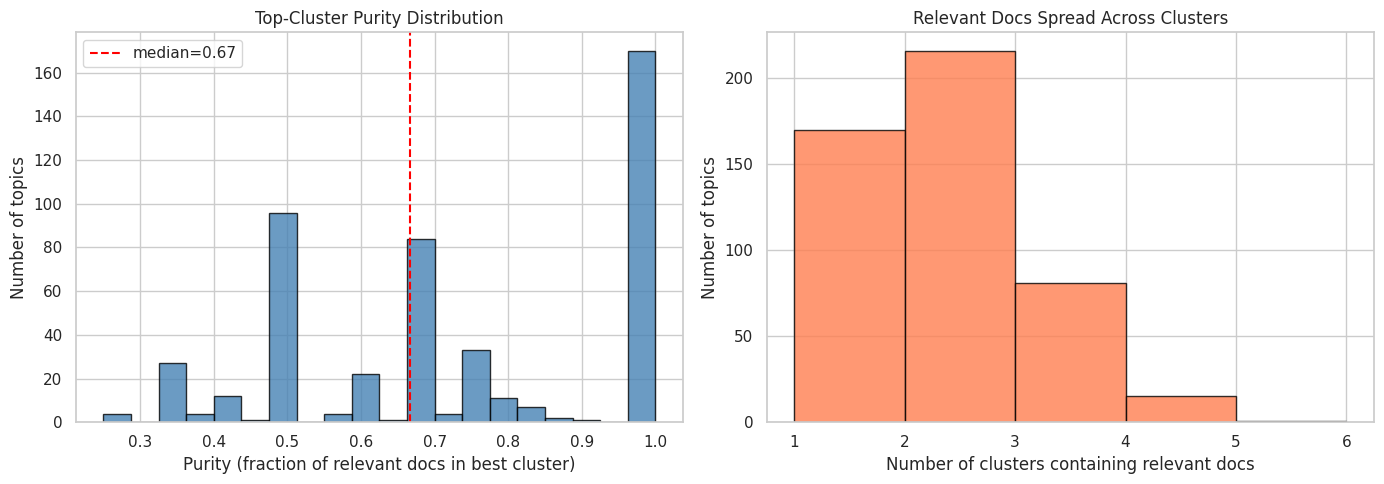

In [5]:
# --- Cluster count distribution ---
n_clusters_per_topic = pd.Series(
    {topic: len(c) for topic, c in clusters.items()}, name="n_clusters"
)
hist_df = n_clusters_per_topic.value_counts().sort_index().rename_axis("n_clusters").reset_index(name="n_topics")

fig = px.bar(
    hist_df, x="n_clusters", y="n_topics",
    title="Distribution of Cluster Count per Topic",
    labels={"n_clusters": "Number of clusters", "n_topics": "Number of topics"},
)
fig.update_traces(marker_line_color="black", marker_line_width=1, opacity=0.85)
fig.update_layout(template="plotly_white", bargap=0.1, xaxis=dict(dtick=1, tickmode="linear"))
fig.show()

# --- Purity distributions ---
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(purity_df["top_purity"], bins=20, edgecolor="black", alpha=0.8, color="steelblue")
axes[0].axvline(purity_df["top_purity"].median(), color="red", linestyle="--",
                label=f'median={purity_df["top_purity"].median():.2f}')
axes[0].set_title("Top-Cluster Purity Distribution")
axes[0].set_xlabel("Purity (fraction of relevant docs in best cluster)")
axes[0].set_ylabel("Number of topics")
axes[0].legend()

max_spread = purity_df["clusters_with_relevant"].max()
axes[1].hist(purity_df["clusters_with_relevant"], bins=range(1, max_spread + 2),
             edgecolor="black", alpha=0.8, color="coral")
axes[1].set_title("Relevant Docs Spread Across Clusters")
axes[1].set_xlabel("Number of clusters containing relevant docs")
axes[1].set_ylabel("Number of topics")

plt.tight_layout()
plt.show()

## 4. Cluster Priority Scoring & Evaluation

Rank clusters per topic using an unsupervised **priority score** combining retrieval strength and graph cohesion:

$$\text{priority} = 0.30 \times \overline{\text{retrieval\_score}} + 0.70 \times \text{graph\_cohesion}$$

where **graph cohesion** = fraction of possible intra-cluster edges above the similarity threshold. The heavy weight on cohesion reflects that dense subgraph structure is more predictive of relevance than raw retrieval scores.

We then select the **top 2–3 clusters** per topic and evaluate on standard IR metrics.

In [6]:
COHESION_THRESHOLD = 0.4
MIN_CANDIDATES = 100

retrieval_df = pd.read_csv(CANDIDATES_PATH, usecols=["topic", "number", "score"])
retrieval_df["score"] = retrieval_df["score"].astype(float)

# --- Compute per-cluster priority scores ---
cluster_rows = []
for topic_raw, topic_clusters in clusters.items():
    topic_retr = retrieval_df[retrieval_df["topic"] == topic_raw]
    score_by_doc = dict(zip(topic_retr["number"], topic_retr["score"]))

    topic_ids = artifacts["topic_doc_ids"].get(topic_raw, [])
    idx_by_doc = {str(d): i for i, d in enumerate(topic_ids)}
    sim_matrix = artifacts["matrices"][topic_raw] if topic_raw in artifacts["matrices"].files else None

    for cluster_id, docs in topic_clusters.items():
        cluster_docs = [str(d) for d in docs]
        scores = [score_by_doc[d] for d in cluster_docs if d in score_by_doc]
        mean_score = float(np.mean(scores)) if scores else 0.0

        indices = [idx_by_doc[d] for d in cluster_docs if d in idx_by_doc]
        n_nodes = len(indices)
        possible = n_nodes * (n_nodes - 1) // 2

        if possible > 0 and sim_matrix is not None:
            sub = sim_matrix[np.ix_(indices, indices)]
            ii, jj = np.triu_indices(n_nodes, k=1)
            actual = int(np.sum(sub[ii, jj] >= COHESION_THRESHOLD))
            cohesion = actual / possible
        else:
            cohesion = 0.0

        cluster_rows.append({
            "topic": topic_raw, "cluster_id": cluster_id,
            "cluster_size": len(cluster_docs), "n_scored": len(scores),
            "mean_retrieval_score": mean_score, "graph_cohesion": cohesion,
            "priority_score": 0.30 * mean_score + 0.70 * cohesion,
        })

cluster_stats = pd.DataFrame(cluster_rows)

# --- Select top 2-3 clusters per topic ---
selected = []
for topic, grp in cluster_stats.groupby("topic", sort=False):
    ranked = grp.sort_values("priority_score", ascending=False)
    top2_count = int(ranked.head(2)["n_scored"].sum())
    n_select = 2 if top2_count >= MIN_CANDIDATES else min(3, len(ranked))
    selected.append(ranked.head(n_select))

best_clusters = pd.concat(selected, ignore_index=True)

# --- Build ranking from selected clusters ---
eval_rows = []
for topic_raw, topic_clusters in clusters.items():
    selected_ids = best_clusters.loc[best_clusters["topic"] == topic_raw, "cluster_id"].tolist()
    if not selected_ids:
        continue
    topic_retr = retrieval_df[retrieval_df["topic"] == topic_raw]
    score_by_doc = dict(zip(topic_retr["number"], topic_retr["score"]))

    seen = set()
    for cid in selected_ids:
        for doc_id in [str(d) for d in topic_clusters.get(cid, [])]:
            if doc_id not in seen and doc_id in score_by_doc:
                eval_rows.append({"topic": topic_raw, "number": doc_id, "score": score_by_doc[doc_id]})
                seen.add(doc_id)

eval_df = pd.DataFrame(eval_rows)
metrics = utils.calculate_metrics(results=eval_df, topk=200, test_topics_path=QRELS_PATH)

print("Cluster-filtered retrieval metrics:")
for k in [5, 10, 20, 50, 100, 200]:
    p = metrics.get(f"precision@{k}", 0)
    r = metrics.get(f"recall@{k}", 0)
    n = metrics.get(f"nDCG@{k}", 0)
    print(f"  @{k:>3d}: precision={p:.4f}  recall={r:.4f}  nDCG={n:.4f}")

print(f"\nTopics evaluated: {eval_df['topic'].nunique()}")
print(f"Mean graph cohesion of selected clusters: {best_clusters['graph_cohesion'].mean():.4f}")

Cluster-filtered retrieval metrics:
  @  5: precision=0.1380  recall=0.1630  nDCG=0.3584
  @ 10: precision=0.1014  recall=0.2333  nDCG=0.3881
  @ 20: precision=0.0679  recall=0.3052  nDCG=0.4040
  @ 50: precision=0.0364  recall=0.4011  nDCG=0.4051
  @100: precision=0.0221  recall=0.4803  nDCG=0.4063
  @200: precision=0.0141  recall=0.5292  nDCG=0.4056

Topics evaluated: 500
Mean graph cohesion of selected clusters: 1.0000


## Key Insights

| Finding | Evidence |
|---------|----------|
| Relevant patents form tight communities | Median top-cluster purity = 1.0; 78.9% of topics have purity ≥ 0.6 |
| Graph cohesion outweighs retrieval score | Optimal priority weight: 70% cohesion, 30% retrieval score |
| Most topics have few clusters | Median ~2–3 clusters per topic among top-500 candidates |
| Cluster-based filtering removes noise | Selecting 2–3 clusters retains relevant docs while discarding false positives |

**Implication:** Leiden clustering on embedding similarity graphs provides a strong unsupervised signal for post-retrieval filtering in patent search. The density of a subgraph (cohesion) is more informative than individual document retrieval scores for identifying clusters that contain relevant patents.